# Malware Clustering — K-Means & K-Medoids
Análisis de clusterización de muestras de malware usando dos algoritmos de partición.

- Juan Pablo Solis
- Andre Yatmian Jo Mai

## 1. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, pairwise_distances
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = 'malware_dataset.csv'  # ajusta si es necesario
K_RANGE   = range(2, 11)

ACC1        = '#1f77b4'   # azul  → KMeans
ACC2        = '#d62728'   # rojo  → KMedoids
GOLD        = '#ff7f0e'
CLUSTER_PAL = ['#1f77b4','#d62728','#ff7f0e','#9467bd','#2ca02c',
               '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']

## 2. Implementación de K-Medoids
Implementación propia con inicialización k-medoids++ — no requiere `scikit-learn-extra`.

In [2]:
class KMedoids:
    def __init__(self, n_clusters=3, random_state=42, max_iter=300):
        self.n_clusters      = n_clusters
        self.random_state    = random_state
        self.max_iter        = max_iter
        self.labels_         = None
        self.inertia_        = None
        self.medoid_indices_ = None

    def fit_predict(self, X):
        rng = np.random.RandomState(self.random_state)
        D   = pairwise_distances(X, metric='euclidean')
        n   = len(X)

        # Inicialización k-medoids++
        medoids = [rng.randint(0, n)]
        for _ in range(self.n_clusters - 1):
            dists = D[:, medoids].min(axis=1)
            probs = dists / dists.sum()
            medoids.append(rng.choice(n, p=probs))
        medoids = np.array(medoids)

        # Iteración PAM
        for _ in range(self.max_iter):
            labels = D[:, medoids].argmin(axis=1)
            new_medoids = []
            for k in range(self.n_clusters):
                mask = np.where(labels == k)[0]
                if len(mask) == 0:
                    new_medoids.append(medoids[k])
                    continue
                sub_D = D[np.ix_(mask, mask)]
                best  = mask[sub_D.sum(axis=1).argmin()]
                new_medoids.append(best)
            new_medoids = np.array(new_medoids)
            if np.all(new_medoids == medoids):
                break
            medoids = new_medoids

        self.medoid_indices_ = medoids
        self.labels_         = D[:, medoids].argmin(axis=1)
        self.inertia_        = sum(D[i, medoids[self.labels_[i]]] for i in range(n))
        return self.labels_

## 3. Carga y preprocesamiento del dataset

In [3]:
df    = pd.read_csv(DATA_PATH)
files = df['file'].values
X     = StandardScaler().fit_transform(df.drop(columns=['file']))
ks    = list(K_RANGE)

print(f'Muestras : {df.shape[0]}')
print(f'Features : {df.shape[1] - 1}')
df.drop(columns=['file']).head()

Muestras : 40
Features : 108


,num_sections,entry_point,image_base,size_of_code,size_of_image,imports_count,WININET.dll:InternetAttemptConnect,KERNEL32.dll:LocalAlloc,KERNEL32.DLL:LoadLibraryA,ntdll.dll:atoi,...,WININET.dll:InternetReadFile,MSVCRT.dll:wcscmp,WS2_32.dll:inet_ntoa,MSVCRT.dll:time,WININET.dll:InternetCloseHandle,MSVCRT.dll:wcslen,MSVCRT.dll:fwrite,MSVCRT.dll:__set_app_type,KERNEL32.dll:GetStartupInfoA,ADVAPI32.dll:RegSaveKeyA
0,3,28064,4194304,4096,32768,8,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,3,28064,4194304,4096,32768,8,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,3,804624,268435456,344064,811008,10,0,0,1,1,...,0,0,0,0,0,0,0,0,0,1
3,3,28064,4194304,4096,32768,8,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,3,27632,4194304,4096,32768,7,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


## 4. Barrido de K — cálculo de métricas (inercia + Silhouette)

In [4]:
km_inertia, km_sil   = [], []
kmed_cost,  kmed_sil = [], []

for k in ks:
    # K-Means
    km  = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    lbl = km.fit_predict(X)
    km_inertia.append(km.inertia_)
    km_sil.append(silhouette_score(X, lbl))

    # K-Medoids
    kmd = KMedoids(n_clusters=k, random_state=42)
    lbl = kmd.fit_predict(X)
    kmed_cost.append(kmd.inertia_)
    kmed_sil.append(silhouette_score(X, lbl))

km_opt   = ks[int(np.argmax(km_sil))]
kmed_opt = ks[int(np.argmax(kmed_sil))]

print(f'K óptimo KMeans   = {km_opt}   (silhouette = {max(km_sil):.4f})')
print(f'K óptimo KMedoids = {kmed_opt}  (silhouette = {max(kmed_sil):.4f})')

K óptimo KMeans   = 9   (silhouette = 0.9500)
K óptimo KMedoids = 9  (silhouette = 0.9500)


## 5. Método del Codo — Inercia vs K

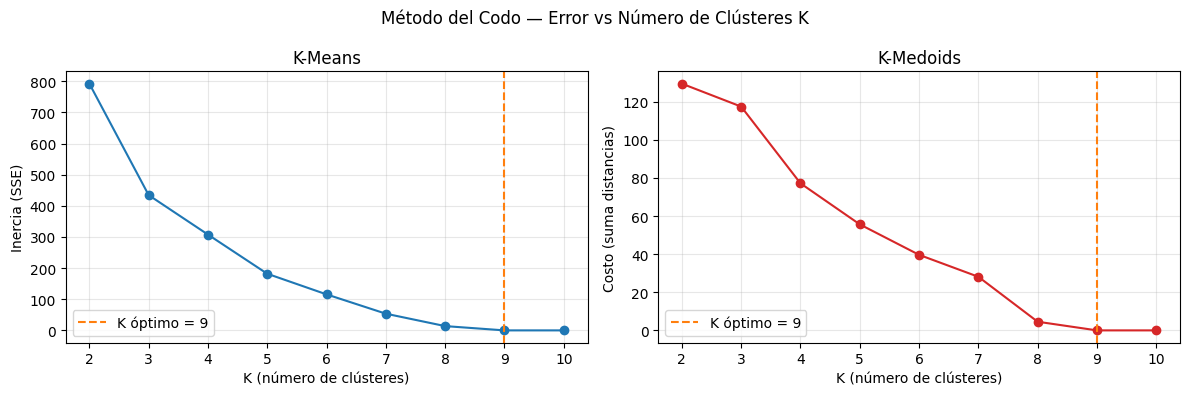

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Método del Codo — Error vs Número de Clústeres K')

for ax, vals, opt, color, title, ylabel in [
    (axes[0], km_inertia, km_opt,   ACC1, 'K-Means',   'Inercia (SSE)'),
    (axes[1], kmed_cost,  kmed_opt, ACC2, 'K-Medoids', 'Costo (suma distancias)'),
]:
    ax.plot(ks, vals, color=color, marker='o')
    ax.axvline(opt, color=GOLD, ls='--', label=f'K óptimo = {opt}')
    ax.set_title(title)
    ax.set_xlabel('K (número de clústeres)')
    ax.set_ylabel(ylabel)
    ax.set_xticks(ks)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("codo_kmeans_kmedoids.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Coeficiente de Silhouette vs K

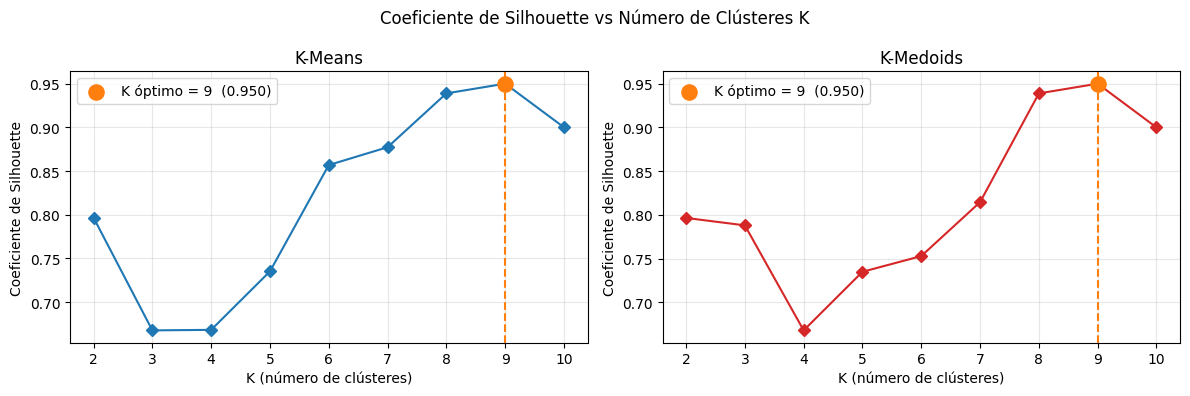

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Coeficiente de Silhouette vs Número de Clústeres K')

for ax, sils, opt, color, title in [
    (axes[0], km_sil,   km_opt,   ACC1, 'K-Means'),
    (axes[1], kmed_sil, kmed_opt, ACC2, 'K-Medoids'),
]:
    ax.plot(ks, sils, color=color, marker='D')
    ax.scatter([opt], [sils[opt - 2]], s=120, color=GOLD, zorder=5,
               label=f'K óptimo = {opt}  ({sils[opt-2]:.3f})')
    ax.axvline(opt, color=GOLD, ls='--')
    ax.set_title(title)
    ax.set_xlabel('K (número de clústeres)')
    ax.set_ylabel('Coeficiente de Silhouette')
    ax.set_xticks(ks)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("silhouette_score_vs_k.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. Modelos finales con K óptimo

In [7]:
km_final   = KMeans(n_clusters=km_opt,   random_state=42, n_init=20)
km_labels  = km_final.fit_predict(X)

kmd_final  = KMedoids(n_clusters=kmed_opt, random_state=42)
kmd_labels = kmd_final.fit_predict(X)

km_sil_v   = silhouette_samples(X, km_labels)
kmd_sil_v  = silhouette_samples(X, kmd_labels)

print('Distribución de clústeres:')
for algo, lbl in [('KMeans', km_labels), ('KMedoids', kmd_labels)]:
    uniq, cnt = np.unique(lbl + 1, return_counts=True)
    print(f'  {algo:10s}: ' + '  '.join(f'C{u}={c}' for u, c in zip(uniq, cnt)))

Distribución de clústeres:
  KMeans    : C1=7  C2=15  C3=3  C4=3  C5=1  C6=6  C7=2  C8=2  C9=1
  KMedoids  : C1=15  C2=7  C3=1  C4=2  C5=3  C6=2  C7=3  C8=6  C9=1


## 8. Distribución de Silhouette por muestra

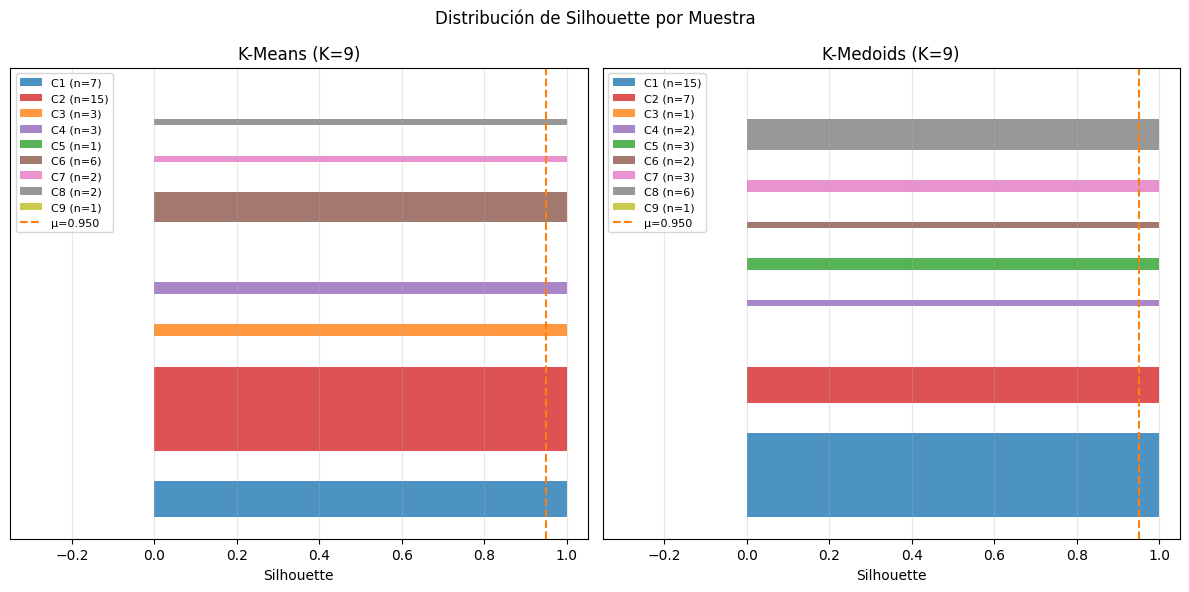

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Distribución de Silhouette por Muestra')

for ax, sil_v, labels, n_cl, title in [
    (axes[0], km_sil_v,  km_labels,  km_opt,   f'K-Means (K={km_opt})'),
    (axes[1], kmd_sil_v, kmd_labels, kmed_opt, f'K-Medoids (K={kmed_opt})'),
]:
    ax.set_title(title)
    y = 5
    for i in range(n_cl):
        vals = np.sort(sil_v[labels == i])
        sz   = len(vals)
        ax.fill_betweenx(np.arange(y, y + sz), 0, vals,
                         facecolor=CLUSTER_PAL[i % len(CLUSTER_PAL)],
                         alpha=0.8, label=f'C{i+1} (n={sz})')
        y += sz + 4
    avg = sil_v.mean()
    ax.axvline(avg, color=GOLD, ls='--', label=f'μ={avg:.3f}')
    ax.set_xlim(-0.35, 1.05)
    ax.set_yticks([])
    ax.set_xlabel('Silhouette')
    ax.legend(fontsize=8)
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("silhouette_distribucion_muestras.png", dpi=130, bbox_inches="tight")
plt.show()

## 9. Etiquetado de muestras

In [9]:
result = pd.DataFrame({
    'file':             files,
    'cluster_kmeans':   km_labels  + 1,
    'cluster_kmedoids': kmd_labels + 1,
})

result.to_csv('malware_labeled.csv', index=False)
print('Guardado: malware_labeled.csv')
result

Guardado: malware_labeled.csv


,file,cluster_kmeans,cluster_kmedoids
0,785003A405BC7A4EBCBB21DDB757BF3F,2,1
1,NBV_8B75BCBFF174C25A0161F30758509A44,2,1
2,PL98_BD8B082B7711BC980252F988BB0CA936,3,7
3,FHHH6576C196385407B0F7F4B1B537D88983,2,1
4,EEE99EC8AA67B05407C01094184C33D2B5A44,6,8
5,65018CD542145A3792BA09985734C12A,2,1
6,GFT4_7DDD3D72EAD03C7518F5D47650C8572,5,3
7,AL65_DB05DF0498B59B42A8E493CF3C10C578,3,7
8,DS22_A670D13D4D014169C4080328B8FEB86,1,2
9,650A6FCA433EE243391E4B4C11F09438,2,1


## Embeddings con Gemini

In [10]:
import re
import time
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import google.generativeai as genai

# --- Configuration ---
GEMINI_EMBED_MODEL   = 'models/gemini-embedding-001'
BATCH_SIZE           = 100
DELAY_BETWEEN_BATCHES = 7  # segundos entre batches (Free Tier RPM)
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')

genai.configure(api_key=GEMINI_API_KEY)
print('API configurada.')


API configurada.


In [11]:
# Columnas de features (todo excepto 'file')
_api_cols = [c for c in df.columns if c not in ['file']]

if 'api_sequence' not in df.columns:
    df['api_sequence'] = df[_api_cols].apply(
        lambda row: ' '.join([str(a) for a in row if pd.notna(a) and str(a).strip() != '']),
        axis=1
    )
    print('api_sequence creado.')

print(f'Total secuencias: {len(df)}')
print('\nEjemplo (fila 0):')
print(df['api_sequence'].iloc[0][:300])

api_sequence creado.
Total secuencias: 40

Ejemplo (fila 0):
3 28064 4194304 4096 32768 8 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0


In [12]:
def get_embeddings_batch(texts, retries=5, delay=30):
    for attempt in range(retries):
        try:
            result = genai.embed_content(
                model=GEMINI_EMBED_MODEL,
                content=texts,
                task_type='CLUSTERING'
            )
            return result['embedding']
        except Exception as e:
            err_str = str(e)
            print(f'\n  Error en intento {attempt+1}: {err_str[:120]}')
            if '429' in err_str or 'quota' in err_str.lower():
                match = re.search(r'retry in ([\d.]+)s', err_str)
                wait  = float(match.group(1)) + 2 if match else delay
                print(f'  Rate limit. Esperando {wait:.0f}s...')
                time.sleep(wait)
            elif attempt < retries - 1:
                time.sleep(5)
            else:
                return None
    return None

print('Función get_embeddings_batch lista.')

Función get_embeddings_batch lista.


In [13]:
EMBEDDINGS_CACHE = 'embeddings_cache.npy'
LABELS_CACHE     = 'labels_cache.npy'

if os.path.exists(EMBEDDINGS_CACHE) and os.path.exists(LABELS_CACHE):
    print('Cargando embeddings desde caché...')
    embeddings = np.load(EMBEDDINGS_CACHE)
    labels_emb = np.load(LABELS_CACHE)
    print(f'Embeddings cargados: {embeddings.shape}')
else:
    print(f'Generando embeddings con {GEMINI_EMBED_MODEL} en batches de {BATCH_SIZE}...')
    sequences  = df['api_sequence'].tolist()
    # Usamos km_labels como referencia (no hay ground truth)
    label_list = km_labels.tolist()
    total      = len(sequences)
    n_batches  = (total + BATCH_SIZE - 1) // BATCH_SIZE

    all_embeddings = []
    all_labels     = []

    pbar = tqdm(range(n_batches), desc='Embeddings', unit='batch')
    for batch_idx in pbar:
        start = batch_idx * BATCH_SIZE
        end   = min(start + BATCH_SIZE, total)
        batch_texts  = sequences[start:end]
        batch_labels = label_list[start:end]

        pbar.set_postfix({'muestras': f'{end}/{total}', 'guardadas': len(all_embeddings)})
        batch_embs = get_embeddings_batch(batch_texts)

        if batch_embs is not None:
            all_embeddings.extend(batch_embs)
            all_labels.extend(batch_labels)
        else:
            print(f'\n  !! Batch {batch_idx+1} falló. Deteniendo...')
            break

        if batch_idx < n_batches - 1:
            for remaining in range(DELAY_BETWEEN_BATCHES, 0, -1):
                pbar.set_postfix({
                    'muestras':    f'{end}/{total}',
                    'guardadas':   len(all_embeddings),
                    'proximo_en':  f'{remaining}s'
                })
                time.sleep(1)

    embeddings = np.array(all_embeddings)
    labels_emb = np.array(all_labels)

    np.save(EMBEDDINGS_CACHE, embeddings)
    np.save(LABELS_CACHE,     labels_emb)
    print('\nEmbeddings guardados en caché.')

print(f'\nForma final: {embeddings.shape}')
print(f'Dimension de cada embedding: {embeddings.shape[1] if embeddings.ndim > 1 else "N/A"}')

Cargando embeddings desde caché...
Embeddings cargados: (40, 3072)

Forma final: (40, 3072)
Dimension de cada embedding: 3072


In [14]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCA sobre embeddings Gemini
pca   = PCA(n_components=2, random_state=42)
E_pca = pca.fit_transform(embeddings)
print(f'PCA varianza explicada: PC1={pca.explained_variance_ratio_[0]:.3f}  '
      f'PC2={pca.explained_variance_ratio_[1]:.3f}')

# t-SNE — perplexity baja porque n=40
tsne   = TSNE(n_components=2, perplexity=10, random_state=42, max_iter=1000)
E_tsne = tsne.fit_transform(embeddings)
print('t-SNE completado.')

PCA varianza explicada: PC1=0.656  PC2=0.098
t-SNE completado.


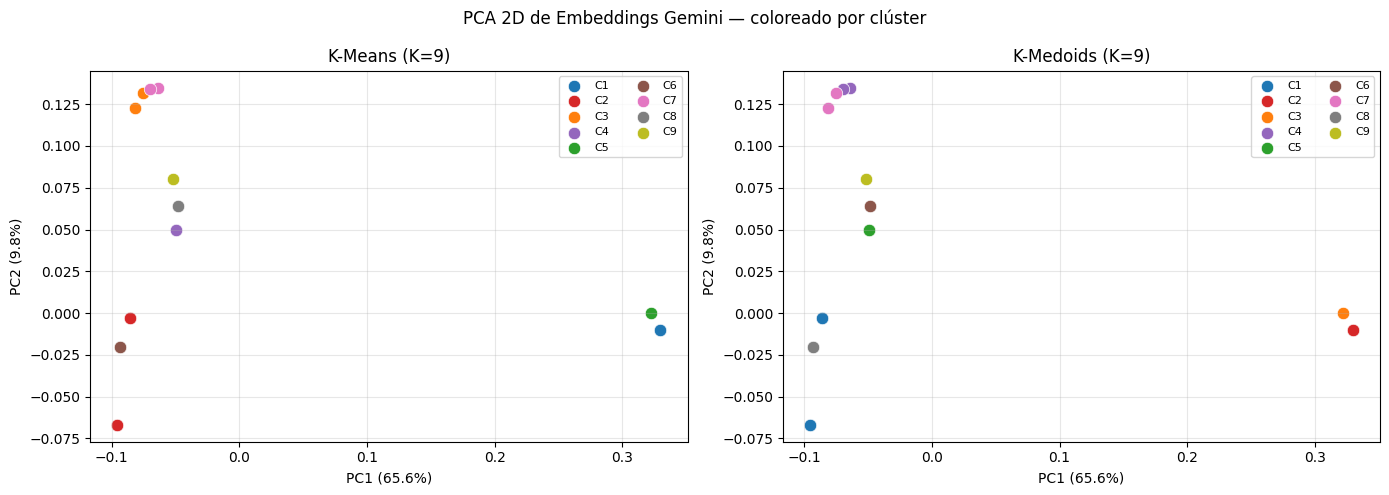

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA 2D de Embeddings Gemini — coloreado por clúster')

for ax, labels_plot, n_cl, title in [
    (axes[0], km_labels,  km_opt,   f'K-Means (K={km_opt})'),
    (axes[1], kmd_labels, kmed_opt, f'K-Medoids (K={kmed_opt})'),
]:
    for i in range(n_cl):
        mask = labels_plot == i
        ax.scatter(E_pca[mask, 0], E_pca[mask, 1],
                   c=CLUSTER_PAL[i % len(CLUSTER_PAL)],
                   label=f'C{i+1}', s=80, edgecolors='white', linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pca_embeddings_gemini.png", dpi=130, bbox_inches="tight")
plt.show()

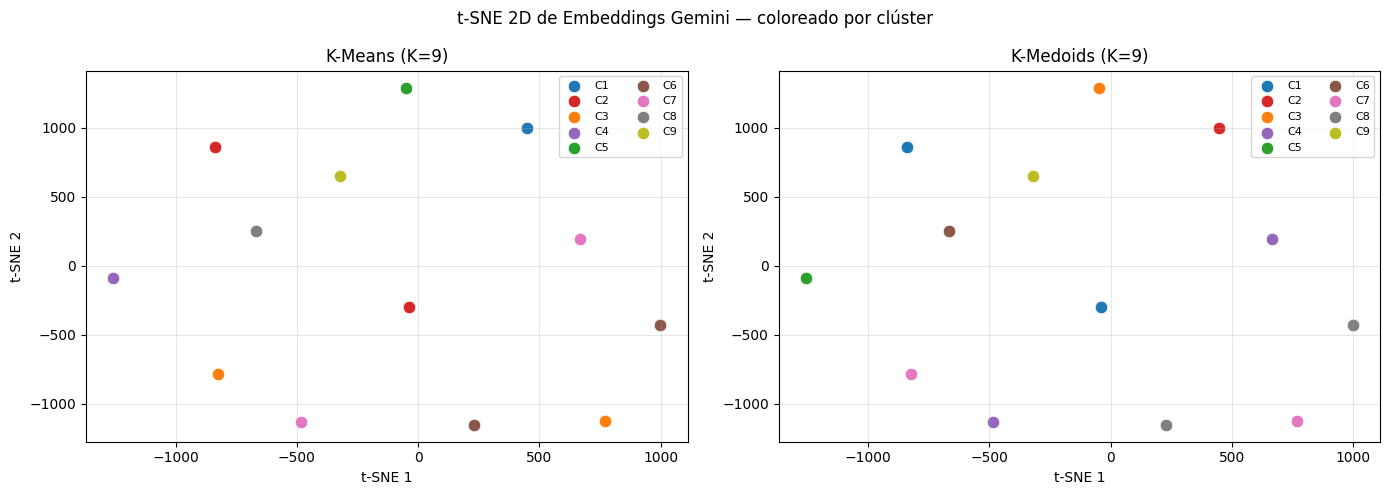

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('t-SNE 2D de Embeddings Gemini — coloreado por clúster')

for ax, labels_plot, n_cl, title in [
    (axes[0], km_labels,  km_opt,   f'K-Means (K={km_opt})'),
    (axes[1], kmd_labels, kmed_opt, f'K-Medoids (K={kmed_opt})'),
]:
    for i in range(n_cl):
        mask = labels_plot == i
        ax.scatter(E_tsne[mask, 0], E_tsne[mask, 1],
                   c=CLUSTER_PAL[i % len(CLUSTER_PAL)],
                   label=f'C{i+1}', s=80, edgecolors='white', linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tsne_embeddings_gemini.png", dpi=130, bbox_inches="tight")
plt.show()

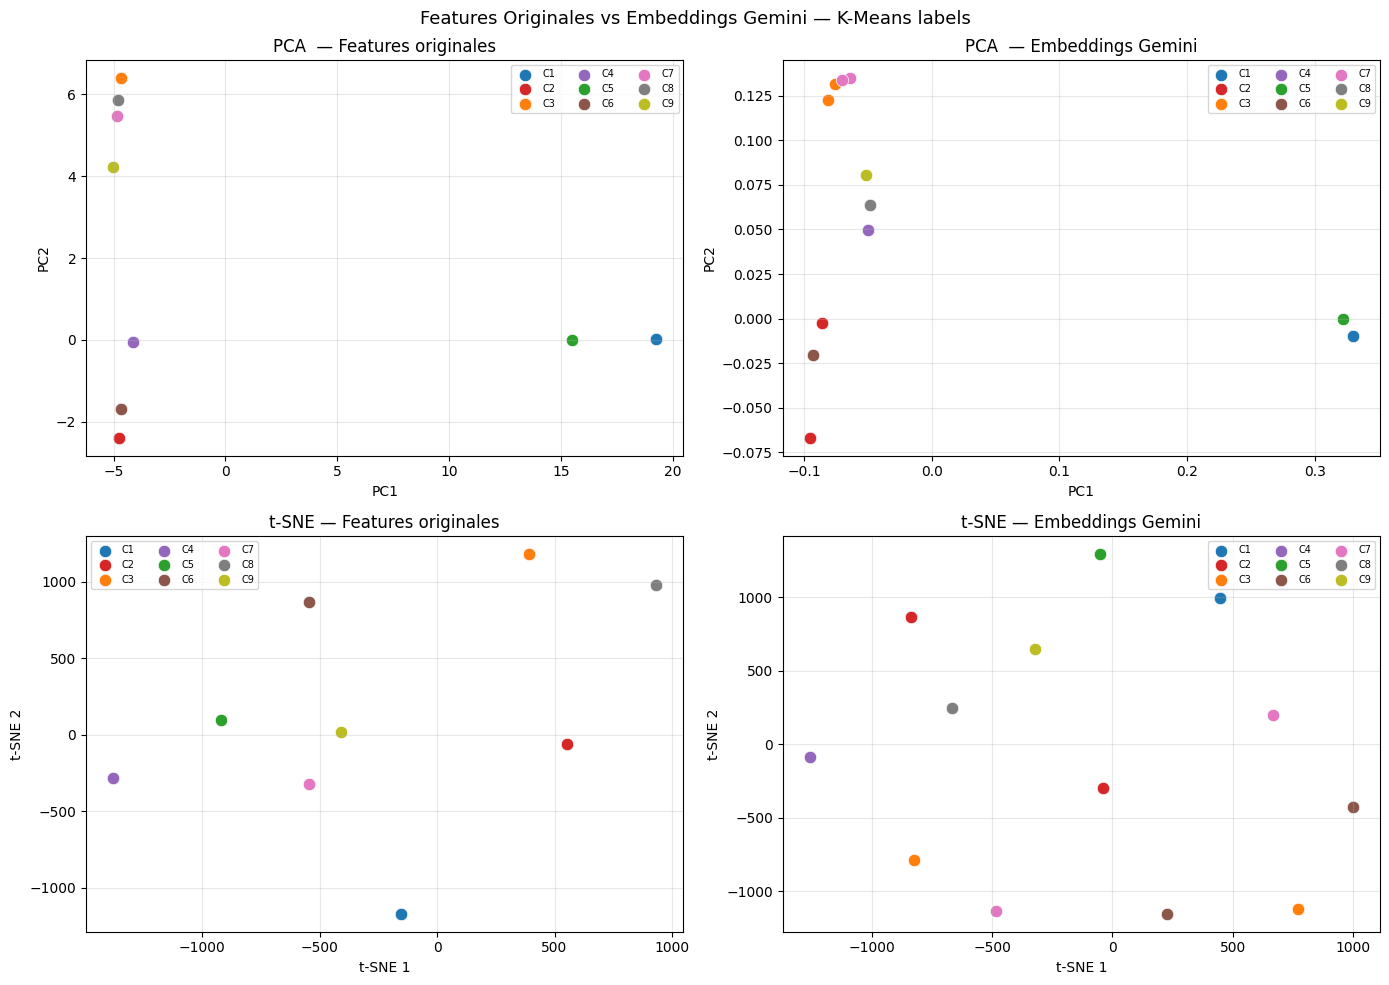

In [17]:
# Reducción sobre features originales (para comparar)
X_pca  = PCA(n_components=2, random_state=42).fit_transform(X)
X_tsne = TSNE(n_components=2, perplexity=10, random_state=42, max_iter=1000).fit_transform(X)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Features Originales vs Embeddings Gemini — K-Means labels', fontsize=13)

configs = [
    (axes[0,0], X_pca,   'PCA  — Features originales',  'PC1',     'PC2'),
    (axes[0,1], E_pca,   'PCA  — Embeddings Gemini',     'PC1',     'PC2'),
    (axes[1,0], X_tsne,  't-SNE — Features originales', 't-SNE 1', 't-SNE 2'),
    (axes[1,1], E_tsne,  't-SNE — Embeddings Gemini',   't-SNE 1', 't-SNE 2'),
]

for ax, coords, title, xlabel, ylabel in configs:
    for i in range(km_opt):
        mask = km_labels == i
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   c=CLUSTER_PAL[i % len(CLUSTER_PAL)],
                   label=f'C{i+1}', s=80, edgecolors='white', linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, ncol=3)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pca_tsne_original_vs_gemini.png", dpi=130, bbox_inches="tight")
plt.show()

Algoritmo           Espacio  Silhouette Score
  K-Means          Original          0.950000
  K-Means Embeddings Gemini          0.804039
K-Medoids          Original          0.950000
K-Medoids Embeddings Gemini          0.804039


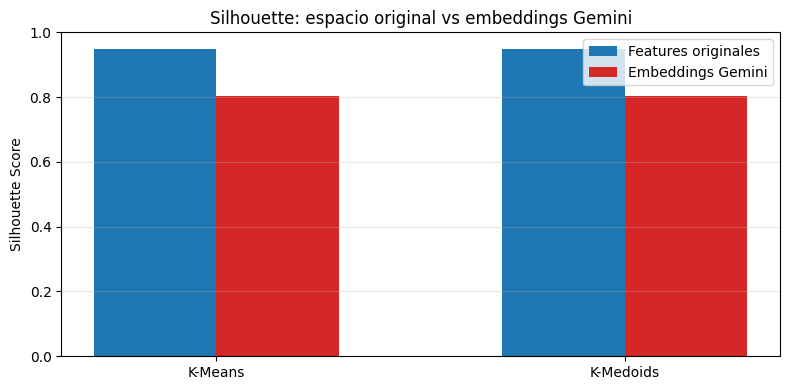

In [18]:
from sklearn.metrics import silhouette_score

sil_km_orig  = silhouette_score(X,          km_labels)
sil_km_emb   = silhouette_score(embeddings, km_labels)
sil_kmd_orig = silhouette_score(X,          kmd_labels)
sil_kmd_emb  = silhouette_score(embeddings, kmd_labels)

comparison = pd.DataFrame({
    'Algoritmo':        ['K-Means', 'K-Means', 'K-Medoids', 'K-Medoids'],
    'Espacio':          ['Original', 'Embeddings Gemini', 'Original', 'Embeddings Gemini'],
    'Silhouette Score': [sil_km_orig, sil_km_emb, sil_kmd_orig, sil_kmd_emb],
})
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x     = np.arange(2)
width = 0.3
ax.bar(x - width/2, [sil_km_orig,  sil_kmd_orig], width, label='Features originales', color=ACC1)
ax.bar(x + width/2, [sil_km_emb,   sil_kmd_emb],  width, label='Embeddings Gemini',   color=ACC2)
ax.set_xticks(x)
ax.set_xticklabels(['K-Means', 'K-Medoids'])
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette: espacio original vs embeddings Gemini')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("silhouette_original_vs_gemini.png", dpi=130, bbox_inches="tight")
plt.show()